# Classification Problem

**Author:** Manaranjan Pradhan</br>
**Website:** www.manaranjanp.com


## 1. HR - Attrition Analytics

Human Resources are critical resources of any organiazation. Organizations spend huge amount of time and money to hire and nuture their employees. It is a huge loss for companies if employees leave, especially the key resources. So if HR can predict weather employees are at risk for leaving the company, it will allow them to identify the attrition risks and help understand and provie necessary support to retain those employees or do preventive hiring to minimize the impact to the orgranization.

## 2. Data Set

This dataset is taken from kaggle https://www.kaggle.com/datasets/jacksonchou/hr-data-for-analytics


### 2.1 Dependent variable

Left : 0 if employee did not leave , 1 if left company

### 2.2 Independent variables

- **satisfaction_level** : means how much employee satisfied (0 less satisfied , 1 most satisfied)
- **last_evaluation** : means employees' evaluation for last month (0 bad , 1 Excellent)
- **number_project** : number of projects the employee worked on
- **average_montly_hours** : average months employee spends at work per month
- **time_spend_company** : years the employee spent in a company
- **Work_accident** : 0 if he did not have an accident , 1 if had at least one
- **promotion_last_5years** : 0 if he did not have any promotion in last 5 years , 1 if had at least one
- **dept** : department in which employee works
- **salary** : High, medium or low bracket

## 3. Loading Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

sn.set_palette("tab10")

In [2]:
hr_df = pd.read_csv('HR_comma_sep.csv')

In [3]:
hr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
hr_df.sample(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,dept,salary
2871,0.77,0.49,4,217,2,0,0,0,support,medium
2904,0.69,0.53,3,142,3,0,0,0,support,low
10269,0.66,0.99,3,228,2,0,0,0,technical,low
11042,0.97,0.89,4,208,2,1,0,0,technical,low
6521,0.72,0.83,3,132,2,0,0,0,technical,medium
10847,0.93,0.91,2,238,2,1,0,0,sales,low
2982,0.64,0.71,3,181,2,0,0,0,technical,low
14465,0.60,0.92,2,258,5,0,1,0,sales,low
4805,0.49,0.61,3,148,2,1,0,0,RandD,low
8681,0.22,0.98,4,185,3,0,0,0,support,low


In [5]:
hr_df.average_montly_hours.min(), hr_df.average_montly_hours.max()

(96, 310)

In [6]:
hr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [7]:
hr_df.left.value_counts()

,count
left,
0,11428
1,3571


## 4. EDA

**Question 1**: How satisfcation level influences employee's decision to leave?

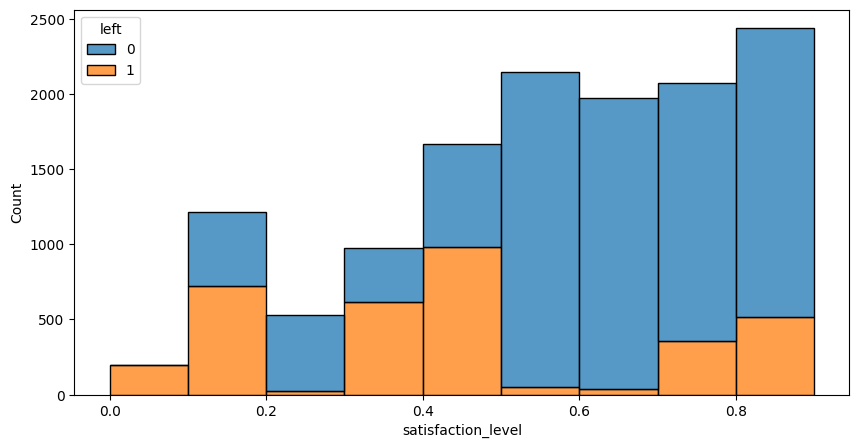

In [8]:
plt.figure(figsize=(10, 5))
sn.histplot(data = hr_df,
            x = 'satisfaction_level',
            hue = 'left',
            bins = np.arange(0.0, 1.0, 0.1),
            multiple="stack");

**Question 2**: How time spend in the company influences employee's decision to leave?

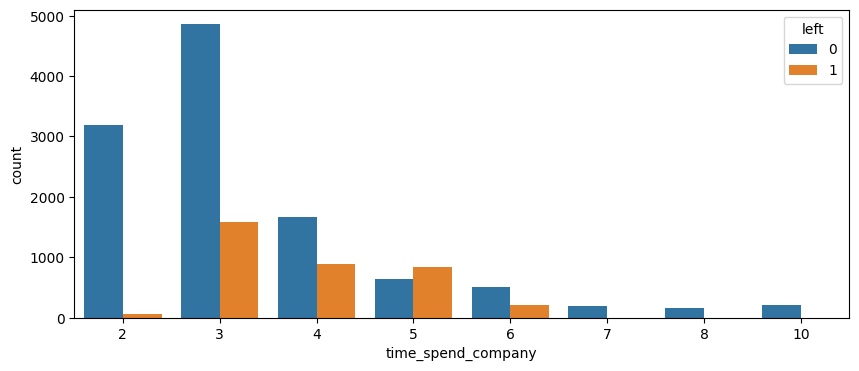

In [9]:
plt.figure(figsize=(10, 4))
sn.countplot(data = hr_df,
             x = 'time_spend_company',
             hue = 'left');

**Question 3**: Attrition patterns across different departments.

In [10]:
hr_df.dept.unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [11]:
pd.crosstab(hr_df.dept,
            hr_df.left,
            normalize='index')

left,0,1
dept,,
IT,0.777506,0.222494
RandD,0.846252,0.153748
accounting,0.734029,0.265971
hr,0.709066,0.290934
management,0.855556,0.144444
marketing,0.763403,0.236597
product_mng,0.780488,0.219512
sales,0.755072,0.244928
support,0.751009,0.248991


In [12]:
pd.crosstab(hr_df.Work_accident,
            hr_df.left,
            normalize='index')

left,0,1
Work_accident,,
0,0.734840,0.265160
1,0.922084,0.077916


# KNN Classification

In [13]:
hr_df.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


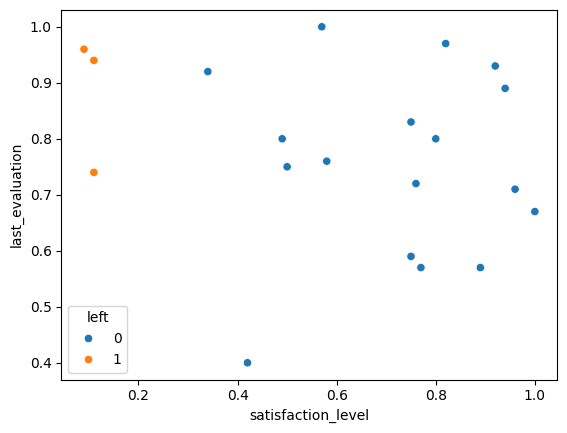

In [14]:
sn.scatterplot(hr_df.sample(20, random_state = 20),
               x = 'satisfaction_level',
               y = 'last_evaluation',
               hue = 'left');

In [15]:
X = hr_df[['satisfaction_level',
           'last_evaluation',
           'average_montly_hours',
           'time_spend_company']]

y = hr_df.left

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 42)

In [18]:
X_train.shape

(11999, 4)

In [19]:
X_test.shape

(3000, 4)

### Build a KNN Model

In [20]:
from sklearn.neighbors import KNeighborsClassifier

In [21]:
knn_v1 = KNeighborsClassifier(n_neighbors = 10)

In [22]:
knn_v1.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=10)

### Evaluate the model

In [23]:
y_knn_pred = knn_v1.predict(X_test)

In [24]:
y_knn_df = pd.DataFrame({"actual" : y_test, "predicted": y_knn_pred})

In [25]:
y_knn_df.sample(10, random_state = 20)

,actual,predicted
3495,0,0
11039,0,0
7864,0,0
8279,0,0
5380,0,0
11932,0,0
1393,1,1
573,1,1
3891,0,0
1315,1,1


# Evaluating Classification Models

- How many correctly classified from the class of left i.e y = 1.
- How many correctly classified from the class of not left i.e y = 0.

**Four Scenarios**:

| Actual | Predicted | Implications |
|---------|----------|--------------|
| Left | Left | **Correct Classification** |
| Left | Not Left |  **Misclassification**: This failure has higher cost. As the model is not able to identify some employees who are likely to leave.   |
| Not Left | Left | **Misclassification**: This failure may not as high cost as the previos one.   |
| Not Left | Not Left | **Correct Classification** |


In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [27]:
cm_knn = confusion_matrix(y_knn_df.actual, y_knn_df.predicted, labels = [1, 0])

In [28]:
cm_knn

array([[ 631,   75],
       [ 105, 2189]])

In [29]:
cm_knn_plot = ConfusionMatrixDisplay(cm_knn, display_labels=['Left', 'Not Left'])

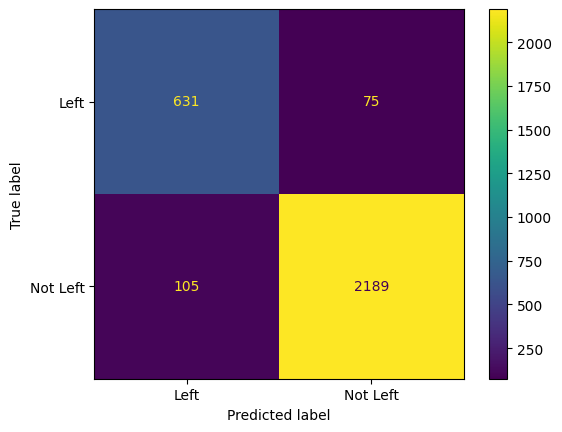

In [30]:
cm_knn_plot.plot();

In [31]:
from sklearn.metrics import classification_report, recall_score

In [32]:
recall_score(y_knn_df.actual, y_knn_df.predicted)

0.8937677053824362

In [33]:
print(classification_report(y_knn_df.actual, y_knn_df.predicted))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96      2294
           1       0.86      0.89      0.88       706

    accuracy                           0.94      3000
   macro avg       0.91      0.92      0.92      3000
weighted avg       0.94      0.94      0.94      3000



### Which is the best K i.e. n_neighbors?

In [34]:
k_vals = list(range(5, 16, 1))

In [35]:
k_vals

[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

In [36]:
from sklearn.metrics import recall_score

In [37]:
for k in k_vals:
    knn_v1 = KNeighborsClassifier(n_neighbors = k)
    knn_v1.fit(X_train, y_train)
    y_knn_pred = knn_v1.predict(X_test)
    y_knn_df = pd.DataFrame({"actual" : y_test,
                             "predicted": y_knn_pred})
    recall_val = recall_score(y_knn_df.actual,
                                y_knn_df.predicted)
    print(f"for n_neighbors: {k} - recall score: {round(recall_val, 3)}")

for n_neighbors: 5 - recall score: 0.911
for n_neighbors: 6 - recall score: 0.902
for n_neighbors: 7 - recall score: 0.919
for n_neighbors: 8 - recall score: 0.899
for n_neighbors: 9 - recall score: 0.908
for n_neighbors: 10 - recall score: 0.894
for n_neighbors: 11 - recall score: 0.908
for n_neighbors: 12 - recall score: 0.884
for n_neighbors: 13 - recall score: 0.895
for n_neighbors: 14 - recall score: 0.89
for n_neighbors: 15 - recall score: 0.902
